In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import Any

from project_root import PROJECT_ROOT,DATASETS_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout


import torchvision as tv

from scripts.model_serialization import load_model

no_grad_guard = torch.no_grad()

2025-04-28 14:39:40.981313: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-28 14:39:40.988652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745843980.997067 2372496 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745843980.999718 2372496 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745843981.006543 2372496 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
###############################################
# This configures which model/dataset we are evaluating
# Identity
# model_path = PROJECT_ROOT / "models/identity/vit/good_freeze_embeddings3/config.ptc"
model_path = Path("/home/dherrera/git/zoo_vision/models/identity/vit/v4/config.json")
dataset_names = [
    "zoo-elephants-identity-v1-curated",
    "zoo-elephants-identity-v1-val",
    "zoo-elephants-identity-d2",
    "zoo-elephants-identity-certainty-good",
    "zoo-elephants-identity-certainty-val",
    "zoo-elephants-identity-id3",
    "zoo-elephants-identity-v4",
]

# Behaviour
# model_path = PROJECT_ROOT / "models/sleep/vit/v2b/checkpoint-7368/config.json"
# dataset_names = [
#     "zoo-elephants-sleep-v1",
#     "zoo-elephants-sleep-v2",
#     "zoo-elephants-sleep-v3",
# ]

# Certainty
# model_path = Path("/home/dherrera/git/zoo_vision/models/certainty/vit/v4/config.json")
# datasets = {name: fo.load_dataset(name) for name in ["zoo-elephants-certainty"]}

###############################################
datasets = {name: fo.load_dataset(name) for name in dataset_names}

ds0 = next(datasets.values().__iter__())
classes = sorted(ds0.classes["ground_truth"])
print(classes)

['01_Chandra', '02_Indi', '03_Fahra', '04_Panang', '05_Thai']


In [3]:
# model_path = PROJECT_ROOT / "models/identity/freeze09/dense121_c5_identity2.pth"
model = load_model(model_path).to(torch.device("cuda"))
model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of the model checkpoint at /home/dherrera/git/zoo_vision/models/identity/vit/v4 were not used when initializing ViTForImageClassification: ['loss_fct.weight']
- This IS expected if you are initializing ViTForImageClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTForImageClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

image_processor.image_mean=[0.48500001430511475, 0.4560000002384186, 0.4059999883174896], image_processor.image_std=[0.2290000021457672, 0.2239999920129776, 0.22499999403953552]
680a5baea4d94645d5fd4a17


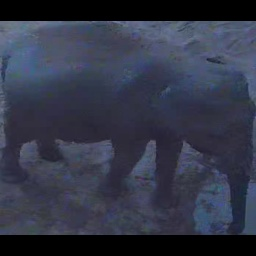

transform_and_preprocess(im0).shape=torch.Size([3, 224, 224])
r0.tolist()=[-0.8927444815635681, 1.9870009422302246, -0.9592775106430054, -1.4349209070205688, -1.2031054496765137]
p0=[0.04748329892754555, 0.8456652164459229, 0.04442689195275307, 0.02761065773665905, 0.03481391444802284]


In [4]:
import PIL

import transformers

image_processor = transformers.AutoImageProcessor.from_pretrained(model_path.parent)
print(f"{image_processor.image_mean=}, {image_processor.image_std=}")


def transform_and_preprocess(image: PIL.Image):
    image = np.asarray(image)
    # image = tv.transforms.Resize([224,224])(image)
    image = image_processor.preprocess(image)["pixel_values"][0]
    image = torch.from_numpy(image)
    # image = image.permute([2,0,1])
    # raise RuntimeError(f"{type(image)}")
    # raise RuntimeError(f"type is {type(image)}, {str(image.shape)=}")
    return image


one_sample = ds0.take(1)
sample0 = next(one_sample.iter_samples())
# sample0 = {
#     "id": "custom",
#     "filepath": "/media/dherrera/ElephantsWD/elephants/improve/behaviour/00_Invalid/2025-04-25/zag_elp_cam_016_002242.jpg"
# }
print(sample0["id"])
im0 = PIL.Image.open(sample0["filepath"])
display(im0)
print(f"{transform_and_preprocess(im0).shape=}")
t0 = transform_and_preprocess(im0).unsqueeze(0).to(torch.device("cuda"))
r0 = model(t0)
r0 = r0["logits"]
r0 = r0.squeeze()
print(f"{r0.tolist()=}")
p0 = torch.nn.functional.softmax(r0, dim=0)
p0 = p0.tolist()
print(f"{p0=}")

In [5]:
config = fout.TorchImageModelConfig(
    {
        "entrypoint_fcn": lambda: model,
        "entrypoint_args": {},
        "output_processor": fout.ClassifierOutputProcessor(
            classes=classes, store_logits=True
        ),
        "classes": classes,
        "transforms": transform_and_preprocess,
        "image_min_dim": 224,
        "image_max_dim": 2048,
    }
)
fo_model = fout.TorchImageModel(config)

print("Applying model to samples...")
# ds_zoo_elephants.apply_model(fo_model, label_field="zoo_identity")
# predictions_view = ds_zoo_elephants.take(100, seed=51)
datasets.pop("all", "no_fail")
for name, ds_i in datasets.items():
    print(f"{name}...")
    ds_i.apply_model(fo_model, label_field="prediction")

# Merge datasets
if fo.dataset_exists("temp"):
    fo.delete_dataset("temp")
ds_all = fo.Dataset("temp")
for ds_i in datasets.values():
    ds_all.merge_samples(ds_i)
datasets["all"] = ds_all

# high_conf_view = predictions_view.filter_labels("zoo maskrcnn", fo.ViewField("confidence") > 0.85, only_matches=False)
# session.view = predictions_view

Applying model to samples...
zoo-elephants-identity-v1-curated...
 100% |███████████████| 6718/6718 [53.3s elapsed, 0s remaining, 123.4 samples/s]      
zoo-elephants-identity-v1-val...
 100% |█████████████████| 186/186 [1.7s elapsed, 0s remaining, 125.7 samples/s]        
zoo-elephants-identity-d2...
 100% |███████████████| 5129/5129 [41.0s elapsed, 0s remaining, 122.4 samples/s]      
zoo-elephants-identity-certainty-good...
 100% |███████████████| 9283/9283 [1.2m elapsed, 0s remaining, 124.7 samples/s]      
zoo-elephants-identity-certainty-val...
 100% |█████████████████| 187/187 [1.7s elapsed, 0s remaining, 123.7 samples/s]      
zoo-elephants-identity-id3...
 100% |█████████████████| 953/953 [7.4s elapsed, 0s remaining, 147.3 samples/s]      
zoo-elephants-identity-v4...
 100% |███████████████| 5000/5000 [39.8s elapsed, 0s remaining, 120.5 samples/s]      


Dataset zoo-elephants-identity-v1-curated
{'01_Chandra': 1119, '02_Indi': 1199, '03_Fahra': 1172, '04_Panang': 910, '05_Thai': 2318}
{'01_Chandra': 1088, '02_Indi': 1224, '03_Fahra': 1172, '04_Panang': 927, '05_Thai': 2307}
              precision    recall  f1-score   support

  01_Chandra       0.97      0.94      0.96      1119
     02_Indi       0.96      0.98      0.97      1199
    03_Fahra       0.97      0.97      0.97      1172
   04_Panang       0.97      0.99      0.98       910
     05_Thai       0.99      0.99      0.99      2318

    accuracy                           0.98      6718
   macro avg       0.97      0.97      0.97      6718
weighted avg       0.98      0.98      0.98      6718



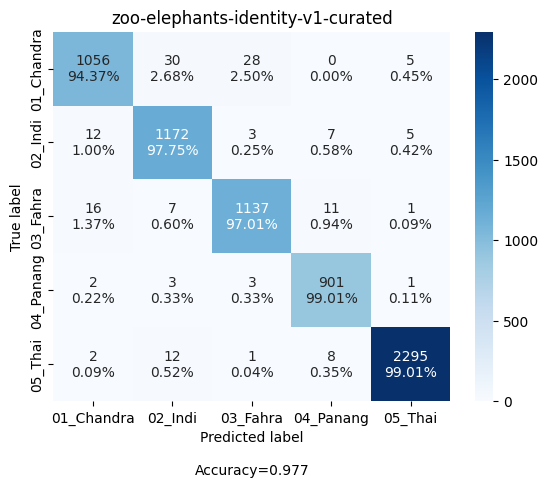

Dataset zoo-elephants-identity-v1-val
{'01_Chandra': 21, '02_Indi': 25, '03_Fahra': 46, '04_Panang': 46, '05_Thai': 48}
{'01_Chandra': 26, '02_Indi': 31, '03_Fahra': 40, '04_Panang': 41, '05_Thai': 48}
              precision    recall  f1-score   support

  01_Chandra       0.81      1.00      0.89        21
     02_Indi       0.71      0.88      0.79        25
    03_Fahra       0.97      0.85      0.91        46
   04_Panang       0.98      0.87      0.92        46
     05_Thai       1.00      1.00      1.00        48

    accuracy                           0.91       186
   macro avg       0.89      0.92      0.90       186
weighted avg       0.93      0.91      0.92       186



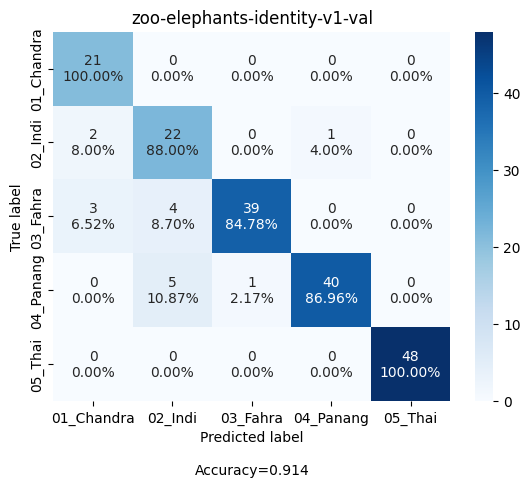

Dataset zoo-elephants-identity-d2
{'01_Chandra': 875, '02_Indi': 818, '03_Fahra': 1049, '04_Panang': 1010, '05_Thai': 1377}
{'01_Chandra': 927, '02_Indi': 878, '03_Fahra': 963, '04_Panang': 1013, '05_Thai': 1348}
              precision    recall  f1-score   support

  01_Chandra       0.88      0.94      0.91       875
     02_Indi       0.89      0.96      0.93       818
    03_Fahra       0.99      0.90      0.94      1049
   04_Panang       0.96      0.96      0.96      1010
     05_Thai       0.98      0.96      0.97      1377

    accuracy                           0.95      5129
   macro avg       0.94      0.95      0.94      5129
weighted avg       0.95      0.95      0.95      5129



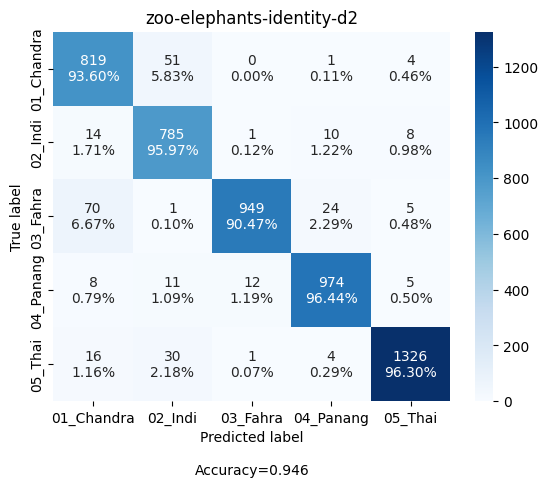

Dataset zoo-elephants-identity-certainty-good
{'01_Chandra': 1465, '02_Indi': 1592, '03_Fahra': 1506, '04_Panang': 1321, '05_Thai': 3399}
{'01_Chandra': 1466, '02_Indi': 1581, '03_Fahra': 1500, '04_Panang': 1338, '05_Thai': 3398}
              precision    recall  f1-score   support

  01_Chandra       0.99      0.99      0.99      1465
     02_Indi       0.99      0.98      0.99      1592
    03_Fahra       1.00      0.99      1.00      1506
   04_Panang       0.99      1.00      0.99      1321
     05_Thai       1.00      1.00      1.00      3399

    accuracy                           0.99      9283
   macro avg       0.99      0.99      0.99      9283
weighted avg       0.99      0.99      0.99      9283



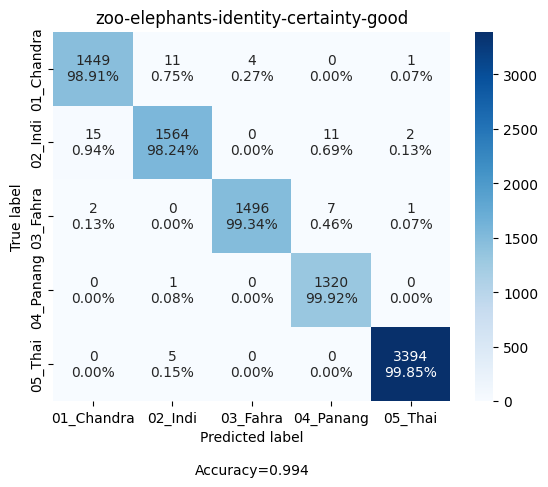

Dataset zoo-elephants-identity-certainty-val
{'01_Chandra': 22, '02_Indi': 25, '03_Fahra': 46, '04_Panang': 46, '05_Thai': 48}
{'01_Chandra': 27, '02_Indi': 31, '03_Fahra': 40, '04_Panang': 41, '05_Thai': 48}
              precision    recall  f1-score   support

  01_Chandra       0.81      1.00      0.90        22
     02_Indi       0.71      0.88      0.79        25
    03_Fahra       0.97      0.85      0.91        46
   04_Panang       0.98      0.87      0.92        46
     05_Thai       1.00      1.00      1.00        48

    accuracy                           0.91       187
   macro avg       0.90      0.92      0.90       187
weighted avg       0.93      0.91      0.92       187



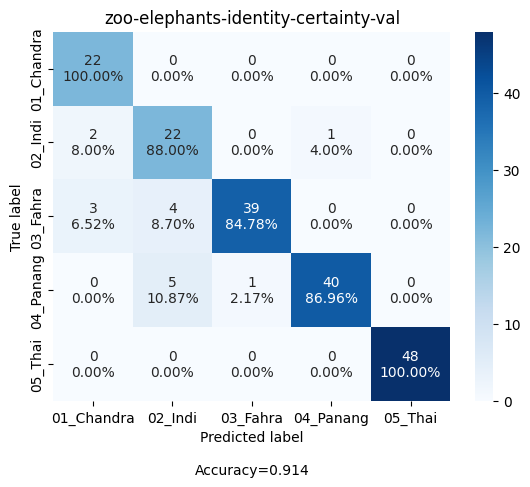

Dataset zoo-elephants-identity-id3
{'01_Chandra': 184, '02_Indi': 178, '03_Fahra': 198, '04_Panang': 197, '05_Thai': 196}
{'01_Chandra': 211, '02_Indi': 163, '03_Fahra': 184, '04_Panang': 195, '05_Thai': 200}
              precision    recall  f1-score   support

  01_Chandra       0.85      0.98      0.91       184
     02_Indi       0.96      0.88      0.92       178
    03_Fahra       0.95      0.88      0.91       198
   04_Panang       0.95      0.94      0.95       197
     05_Thai       0.98      1.00      0.99       196

    accuracy                           0.94       953
   macro avg       0.94      0.94      0.94       953
weighted avg       0.94      0.94      0.94       953



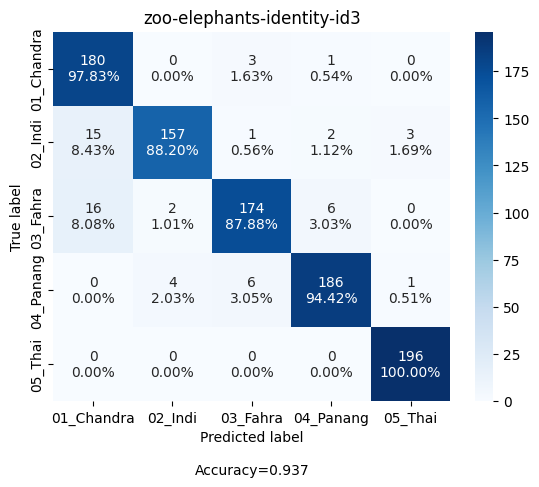

Dataset zoo-elephants-identity-v4
{'01_Chandra': 1000, '02_Indi': 1000, '03_Fahra': 1000, '04_Panang': 1000, '05_Thai': 1000}
{'01_Chandra': 1027, '02_Indi': 1044, '03_Fahra': 958, '04_Panang': 966, '05_Thai': 1005}
              precision    recall  f1-score   support

  01_Chandra       0.92      0.95      0.94      1000
     02_Indi       0.90      0.94      0.92      1000
    03_Fahra       0.95      0.91      0.93      1000
   04_Panang       0.96      0.93      0.95      1000
     05_Thai       0.98      0.98      0.98      1000

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



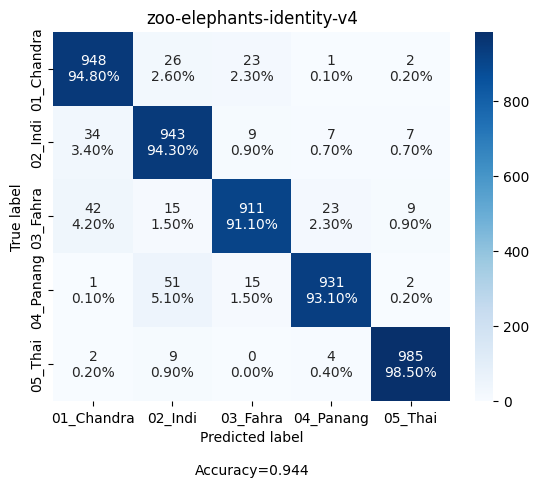

Dataset all
{'01_Chandra': 4686, '02_Indi': 4837, '03_Fahra': 5017, '04_Panang': 4530, '05_Thai': 8386}
{'01_Chandra': 4772, '02_Indi': 4952, '03_Fahra': 4857, '04_Panang': 4521, '05_Thai': 8354}
              precision    recall  f1-score   support

  01_Chandra       0.94      0.96      0.95      4686
     02_Indi       0.94      0.96      0.95      4837
    03_Fahra       0.98      0.95      0.96      5017
   04_Panang       0.97      0.97      0.97      4530
     05_Thai       0.99      0.99      0.99      8386

    accuracy                           0.97     27456
   macro avg       0.96      0.97      0.97     27456
weighted avg       0.97      0.97      0.97     27456



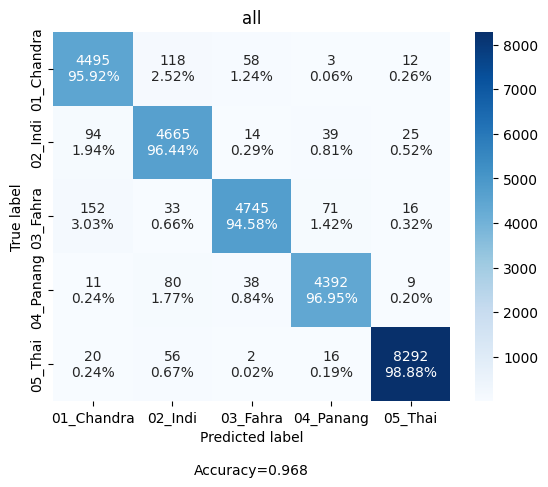

In [6]:
import seaborn as sns
from scripts.cf_matrix import make_confusion_matrix

for ds_i in datasets.values():
    ds_i.delete_evaluations()

for name, ds_i in datasets.items():
    print(f"Dataset {name}")
    ds_i.delete_evaluations()
    results = ds_i.evaluate_classifications(
        pred_field="prediction",
        gt_field="ground_truth",
        eval_key="eval",
        method="simple",
        classes=classes,
    )
    gt_counts = dict(sorted(ds_i.count_values("ground_truth.label").items()))
    pd_counts = dict(sorted(ds_i.count_values("prediction.label").items()))
    print(gt_counts)
    print(pd_counts)
    results.print_report()

    m = results.confusion_matrix()
    # sns.heatmap(m, annot=True,xticklabels=classes, yticklabels=classes, fmt="d")
    make_confusion_matrix(m, categories=classes)
    plt.gca().set_title(name)
    plt.show()

In [7]:
from fiftyone import ViewField as F

ds = next(datasets.values().__iter__())
session = fo.launch_app(ds, auto=False)

session.view = (
    ds
    # .match_tags("validation")
    .match(F("prediction.label") != F("ground_truth.label"))
    # .sort_by("uniqueness", reverse=True)
)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>